In [1]:
import numpy as np
import matplotlib.pyplot as plt
from debug_eye_matching import (
    visualize_eye_points,
    visualize_face_vs_all_bodies_with_skeleton,
    visualize_bodies_bbox_and_skeleton,
    visualize_bodies_bbox_and_skeleton_folder,
)

In [2]:
body_npz = "../video_002/002_body.npz"
face_npz = "../video_002/002_face.npz"

scene_name = "scene_1"
body_id = "body_1"
face_id = "face_0"

with np.load(body_npz, allow_pickle=True) as data:
    body_data = data["bodies"].item()

with np.load(face_npz, allow_pickle=True) as data:
    face_data = data["faces"].item()

scene_bodies = body_data[scene_name]
face = face_data[scene_name][face_id]

In [3]:
nose_avg = np.mean(np.array(face["nose_2d"], dtype=np.float64), axis=1)
leye_avg = np.mean(np.array(face["leye_2d"], dtype=np.float64), axis=1)
reye_avg = np.mean(np.array(face["reye_2d"], dtype=np.float64), axis=1)

print("nose_avg:", nose_avg.shape)
print("leye_avg:", leye_avg.shape)
print("reye_avg:", reye_avg.shape)

nose_avg: (254, 2)
leye_avg: (254, 2)
reye_avg: (254, 2)


In [4]:
frame_idx = 238
image_path = f"../video_002/frame.jpg"

In [5]:

vitpose_all = {
    bid: np.asarray(body["vitpose"], dtype=np.float64)
    for bid, body in scene_bodies.items()
}

vitpose_target = vitpose_all[body_id]


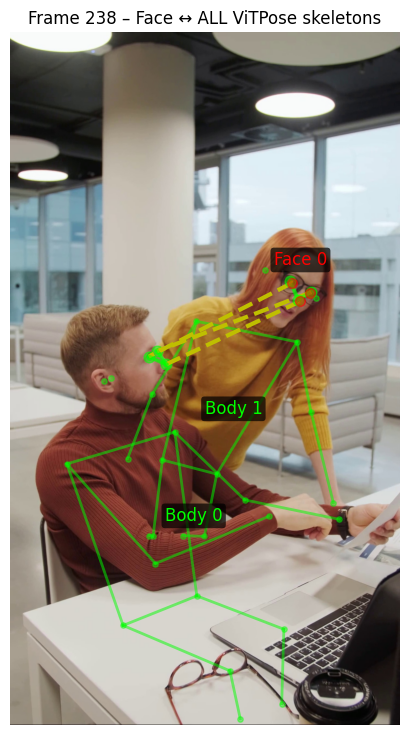

In [6]:
visualize_face_vs_all_bodies_with_skeleton(
    image_path=image_path,
    nose_avg=nose_avg,
    leye_avg=leye_avg,
    reye_avg=reye_avg,
    vitpose_all=vitpose_all,
    frame_idx=frame_idx,
)

In [7]:
vitpose_all = {
    bid: {
        "vitpose": np.asarray(body["vitpose"], dtype=np.float32),
        "bbox_xyxy": np.asarray(body.get("bbox_xyxy"), dtype=np.float32),
    }
    for bid, body in scene_bodies.items()
}

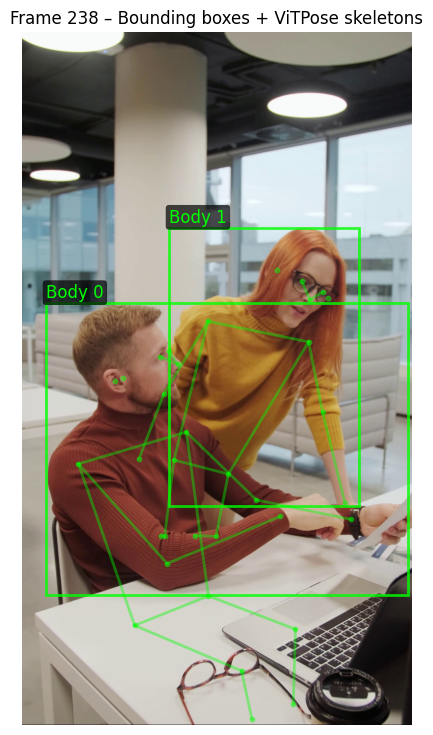

In [8]:
visualize_bodies_bbox_and_skeleton(
    image_path=image_path,
    vitpose_all=vitpose_all,
    frame_idx=frame_idx,
)

In [9]:
image_dir="../video_002/frames_teaser/"
visualize_bodies_bbox_and_skeleton_folder(
    image_dir=image_dir, vitpose_all=vitpose_all, frame_stride=41, output_dir=image_dir+"treatment/"
)

0
0
41
41
82
82
123
123
164
164
205
205
246
246
